<a href="https://colab.research.google.com/github/ladypluvia/Spotify_Bootstrap_MiniProje/blob/main/Bootstrap_Mini_Proje_Spotify_soru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎧 Mini Proje: "Spotify Wrapped"in Arkasındaki İstatistik
---

### 📖 Hikâye

Yıl sonu yaklaşıyor, Spotify'ın o ünlü **Wrapped** kampanyasından önce şirket sizi
(yeni kurulan **"Insights" ekibinin junior data analistini**) küçük ama kritik bir göreve atıyor:

> *"Türkiye'deki kullanıcılarımızın günlük dinleme alışkanlıklarını anlamamız gerekiyor.*
> *Reklamcılarımıza ve müzik şirketlerine sunum yapacağız.*
> *Ama bütçemiz kısıtlı — sadece **75 kullanıcıdan** veri toplayabildik.*
> *Bu küçük örneklemden güvenilir sonuçlar çıkarabilir misin?"*

Veriler elinize ulaşıyor: Bir hafta boyunca rastgele seçilmiş **40 Z kuşağı (18–25 yaş)**
ve **35 Y kuşağı (30–40 yaş)** kullanıcının **günlük ortalama dinleme süreleri** (dakika).

İlk bakışta veriye göz atıyorsunuz ve bir şeyi fark ediyorsunuz:

- Çoğu kullanıcı günde 30–60 dakika arası dinliyor.
- Ama bazı **"süper-dinleyiciler"** var — günde 3 saat üstü!
- Histogramlara bakınca dağılım hiç de **çan eğrisi** gibi durmuyor; sağa doğru uzun bir kuyruk var.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(2024)  # Sonuçların tekrarlanabilir olması için

In [ ]:
# Sahadan toplanan veri

# Z kuşağı (18-25 yaş) - 40 kullanıcının dinleme süresi
z_kusagi = np.random.lognormal(mean=4.2, sigma=0.7, size=40).round(0)

# Y kuşağı (30-40 yaş) - 35 kullanıcının dinleme süresi
y_kusagi = np.random.lognormal(mean=3.7, sigma=0.5, size=35).round(0)

# tüm dinleyicilerin dinleme süresi
dinleme = np.concatenate([z_kusagi, y_kusagi])
# tüm dinleyicilerin haftalık uygulama açma sıklığı:
session_sayisi = (0.18 * dinleme + np.random.normal(8, 6, size=len(dinleme))).round(0)
session_sayisi = np.clip(session_sayisi, 1, None)

**Normallik Testi**
---
Veri normal dağılıyor mu? Ortalama ve medyan neden farklı çıkıyor?

In [ ]:
print("Veri:", dinleme)
print("---"*10)
print(f"Ortalama : {dinleme.mean():.2f}")
print(f"Std Sapma : {dinleme.std():.2f}")
print(f"Medyan : {np.median(dinleme):.2f}")

Veri: [214. 112.  58.  60. 127. 150.  11.  26.  92.  72. 139. 208.  23.  55.
 154. 122.  50.  56. 129.  39.  77. 179.  24.  24. 133.  36.  52.  23.
  52. 104. 108. 113.  24.  49.  41.  61. 149.  84.  61.  76.  66.  41.
  54.  33.  41.  34.  61.  42.  21.  24.  34.  44. 100.  53.  31.  64.
  74.  41.  67.  22.  98.  28.  46.  19.  51.  57.  12.  40.  31.  51.
  19. 106.  38.  35.  26.]
------------------------------
Ortalama : 66.28
Std Sapma : 45.50
Medyan : 52.00


Medyan ortalamanın solunda kalmaktadır, dolayısıyla verinin sağa çarpık olduğunu söyleyebiliriz. Daha güvenilir istatistikler elde etmek için bootstrap yöntemini kullanalım.

In [ ]:
n_bootstrap = 10000
n = len(dinleme)
bootstrap_ortalamalar = []
for i in range(n_bootstrap):
 # Yerine koyarak n kadar örnek seç
 orneklem = np.random.choice(dinleme, size=n)
 bootstrap_ortalamalar.append(orneklem.mean())
bootstrap_ortalamalar=np.array(bootstrap_ortalamalar)

/tmp/ipykernel_12446/4054569392.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_12446/4054569392.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=9)


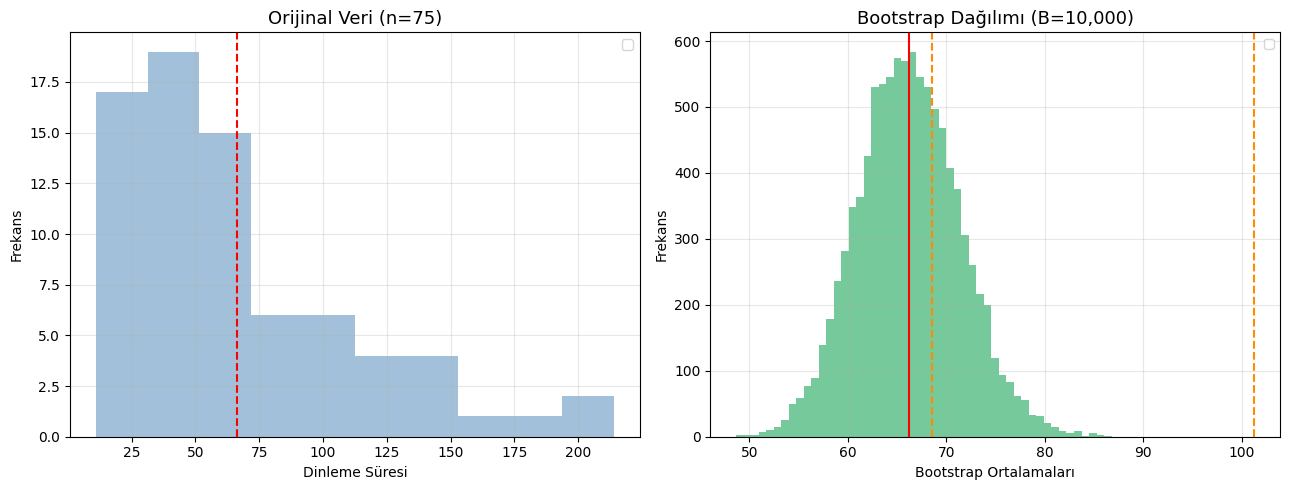

In [ ]:
# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Sol: Orijinal veri dağılımı
axes[0].hist(dinleme, alpha=0.5, color='steelblue')
axes[0].axvline(dinleme.mean(), color='red', linestyle='--')
axes[0].set_title('Orijinal Veri (n=75)', fontsize=13)
axes[0].set_xlabel('Dinleme Süresi')
axes[0].set_ylabel('Frekans')
axes[0].legend()
axes[0].grid(alpha=0.3)
# Sağ: Bootstrap dağılımı + güven aralığı
axes[1].hist(bootstrap_ortalamalar, bins=50,
 alpha=0.7, color='mediumseagreen')
axes[1].axvline(ci_lower, color='darkorange', linestyle='--')
axes[1].axvline(ci_upper, color='darkorange', linestyle='--')
axes[1].axvline(bootstrap_ortalamalar.mean(), color='red', linestyle='-')
axes[1].set_title(f'Bootstrap Dağılımı (B={n_bootstrap:,})', fontsize=13)
axes[1].set_xlabel('Bootstrap Ortalamaları')
axes[1].set_ylabel('Frekans')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

Orijinal veriye baktığımızda sağa çarpık olduğunu gözlemleriz. Dolayısıyla orijinal veriye dayanarak hesapladığımız istatistiklerde çarpıklıktan kaynaklı hatalı sonuçlar bulabilirdik.

Boostrap verisi bize daha güvenilir (%95 güvenle) bir güven aralığı çıkarmıştır.

**Z-Kuşağı için Güven Aralığı**
-------------------------
Z kuşağının günlük ortalama dinleme süresi için %95 güven aralığı nedir

In [ ]:
# Z kuşağı için bootstrap
n_bootstrap = 10000
n_z = len(z_kusagi)
bootstrap_ortalamalar_z = []
for i in range(n_bootstrap):
 # Yerine koyarak n kadar örnek seç
 orneklem_z = np.random.choice(z_kusagi, size=n_z)
 bootstrap_ortalamalar_z.append(orneklem_z.mean())
bootstrap_ortalamalar_z=np.array(bootstrap_ortalamalar_z)

# Y kuşağı için bootstrap
n_bootstrap = 10000
n_y = len(y_kusagi)
bootstrap_ortalamalar_y = []
for i in range(n_bootstrap):
 # Yerine koyarak n kadar örnek seç
 orneklem_y = np.random.choice(y_kusagi, size=n_y)
 bootstrap_ortalamalar_y.append(orneklem_y.mean())
bootstrap_ortalamalar_y=np.array(bootstrap_ortalamalar_y)

In [ ]:
# %95 Güven Aralığı — Percentile (yüzdelik) yöntemi
ci_lower = np.percentile(bootstrap_ortalamalar_z, 2.5)
ci_upper = np.percentile(bootstrap_ortalamalar_z, 97.5)
print(f"Z kuşağı için Bootstrap %95 Güven Aralığı : [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"Genişlik : {ci_upper - ci_lower:.2f} puan")

Z kuşağı için Bootstrap %95 Güven Aralığı : [68.53, 101.25]
Genişlik : 32.73 puan


**Medyan için Güven Aralığı**
-------------------
Aykırı değerlerin etkisini azaltmak için medyan için güven aralığı kuralım. Hangisi daha güvenilir?

In [ ]:
bs_medyanlar_z = []
for i in range(n_bootstrap):
 orneklem_z = np.random.choice(z_kusagi, size=len(z_kusagi), replace=True)
 bs_medyanlar_z.append(np.median(orneklem_z))
bs_medyanlar_z=np.array(bs_medyanlar_z)
ci_med_z = np.percentile(bs_medyanlar_z, [2.5, 97.5])

bs_medyanlar_y = []
for i in range(n_bootstrap):
 orneklem_y = np.random.choice(y_kusagi, size=len(y_kusagi), replace=True)
 bs_medyanlar_y.append(np.median(orneklem_y))
bs_medyanlar_y=np.array(bs_medyanlar_y)
ci_med_y = np.percentile(bs_medyanlar_y, [2.5, 97.5])


print("── Medyan_Z ───────────────────────────────────────────")
print(f" Nokta tahmini : {np.median(z_kusagi):.0f} DK")
print(f" %95 Güven Aralığı : [{ci_med_z[0]:.0f}, {ci_med_z[1]:.0f}] DK")
print(f" Genişlik : {ci_med_z[1]-ci_med_z[0]:.0f} DK")
print()
print("── Medyan_Y ─────────────────────────────────────────────")
print(f" Nokta tahmini : {np.median(y_kusagi):.0f} DK")
print(f" %95 Güven Aralığı : [{ci_med_y[0]:.0f}, {ci_med_y[1]:.0f}] DK")
print(f" Genişlik : {(ci_med_y[1]-ci_med_y[0]):.0f} DK")

── Medyan_Z ───────────────────────────────────────────
 Nokta tahmini : 66 DK
 %95 Güven Aralığı : [54, 106] DK
 Genişlik : 52 DK

── Medyan_Y ─────────────────────────────────────────────
 Nokta tahmini : 41 DK
 %95 Güven Aralığı : [34, 51] DK
 Genişlik : 17 DK


Z kuşağına ait veride güven aralığı genişliği Y kşağına ait veriye göre daha fazladır. Dolayısıyla Y verisinin daha dar bir genişliğe sahip olması onu daha güvenilir yapar.

0.05 anlamlılık düzeyinde y_kusagi verisi daha güvenilirdir.



**Kuşaklar Arasında En Çok Müzik Dinleyen Hangisi?**
----------------------
Z kuşağı, Y kuşağından gerçekten daha mı çok müzik dinliyor? İki grup arasındaki farkın güven aralığını bootstrap ile bulun.

In [ ]:
# Permütasyon Testi
n_perm = 10000
gercek_fark = z_kusagi.mean() - y_kusagi.mean()

perm_farklar = []
for i in range(n_perm):
 # Etiketleri karıştır: "H₀ altında kim Netflix kim Disney+ önemli değil"
 karisik = np.random.permutation(dinleme)
 perm_Z = karisik[:len(z_kusagi)]
 perm_Y = karisik[len(y_kusagi):]
 perm_farklar.append(perm_Z.mean() - perm_Y.mean())
# İki yönlü p-değeri
p_perm = np.mean(np.abs(perm_farklar) >= np.abs(gercek_fark))
print(f"Gözlenen fark : {gercek_fark:.3f}")
print(f"Permütasyon p-değeri (2-yön): {p_perm:.4f}")
if p_perm < 0.05:
 print(" H₀ Reddedildi: Platformda dinleme uzunluğu jenerasyona göre değişiklik gösterir.")
else:
 print(" H₀ Reddedilemedi: Fark istatistiksel olarak anlamlı değil.")

Gözlenen fark : 38.346
Permütasyon p-değeri (2-yön): 0.0000
 H₀ Reddedildi: Platformda dinleme uzunluğu jenerasyona göre değişiklik gösterir.


In [ ]:
# Bootstrap ile hem ortalama hem de medyan için güven aralığı
n_bootstrap = 10000
bs_ortalamalar = []
bs_medyanlar = []
for i in range(n_bootstrap):
  orneklem = np.random.choice(dinleme, size=len(dinleme), replace=True)
  bs_ortalamalar.append(orneklem.mean())
  bs_medyanlar.append(np.median(orneklem))

bs_ortalamalar=np.array(bs_ortalamalar)
bs_medyanlar=np.array(bs_medyanlar)

ci_ort = np.percentile(bs_ortalamalar, [2.5, 97.5])
ci_med = np.percentile(bs_medyanlar, [2.5, 97.5])

print("── Ortalama ───────────────────────────────────────────")
print(f" Nokta tahmini : {dinleme.mean():.0f} dakika")
print(f" %95 Güven Aralığı : [{ci_ort[0]:.0f}, {ci_ort[1]:.0f}] dakika")
print(f" Genişlik : {ci_ort[1]-ci_ort[0]:.0f} dakika")
print()
print("── Medyan ─────────────────────────────────────────────")
print(f" Nokta tahmini : {np.median(dinleme):.0f} dakika")
print(f" %95 Güven Aralığı : [{ci_med[0]:.0f}, {ci_med[1]:.0f}] dakika")
print(f" Genişlik : {(ci_med[1]-ci_med[0]):.0f} dakika")

── Ortalama ───────────────────────────────────────────
 Nokta tahmini : 66 dakika
 %95 Güven Aralığı : [56, 77] dakika
 Genişlik : 21 dakika

── Medyan ─────────────────────────────────────────────
 Nokta tahmini : 52 dakika
 %95 Güven Aralığı : [42, 61] dakika
 Genişlik : 19 dakika


**Korelasyon Analizi**
-----------------
Dinleme süresi ile uygulama açma sıklığı (session_sayisi) arasında nasıl bir ilişki var? bunun için saçılım grafiğini çiziniz. Korelasyon katsayısı için bootstrap güven aralığı kuralım.

<Axes: xlabel='dinleme_suresi', ylabel='session_sayisi'>

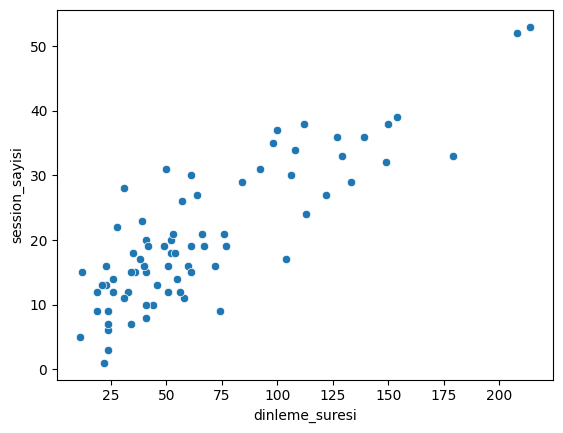

In [ ]:
df = pd.DataFrame({'dinleme_suresi': dinleme, 'session_sayisi': session_sayisi})
sns.scatterplot(data=df, x='dinleme_suresi', y='session_sayisi')

In [ ]:
# 1. Korelasyon
gercek_r = np.corrcoef(dinleme, session_sayisi)[0, 1]
print(f"Gözlenen korelasyon: r = {gercek_r:.4f}")
# 2. Bootstrap güven aralığı
n = len(session_sayisi)
n_boot = 10000
boot_r = []
for i in range(n_boot):
 idx= np.random.choice(n, size=n, replace=True)
 boot_r.append(np.corrcoef(session_sayisi[idx], dinleme[idx])[0, 1])
ci = np.percentile(boot_r, [2.5, 97.5])
print(f"%95 Bootstrap Güven Aralığı: [{ci[0]:.4f}, {ci[1]:.4f}]")

Gözlenen korelasyon: r = 0.8480
%95 Bootstrap Güven Aralığı: [0.7514, 0.9080]
